# V3 grid search — 216 pre-registered cells

3 roots × 2 arms × (4 entry_richness × 3 max_hold × 3 take_profit). The grid was fixed **before**
the first run; see `docs/superpowers/specs/2026-08-14-v3-basis-vs-swaption-preregistration.md`.

The leaderboard is not the answer. **E[max Sharpe | null] is the first column to read**, because
the maximum of 216 correlated cells is a large number even when nothing is there.


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys, json, warnings, pathlib
warnings.filterwarnings("ignore")
sys.path.insert(0, r"C:\Users\chris\clee\ARBS-bv3")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace as _rep
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

from RVUtils.BasisVsVol import v3 as V3, analytics as A
from RVUtils.BasisVsVol.build_basis_panel import filter_data_ok

DATA = pathlib.Path(r"C:\Users\chris\clee\ARBS-bv3") / "notebooks" / "backtests" / "basis_vs_vol" / "_data"
RESULTS = DATA.parent / "_results"

def load_panel(root, start="2019-01-01", end="2026-08-11"):
    """Through the SHARED gate. An inline re-implementation is how the notebook and the runner
    came to disagree about which days exist, and it left is_roll stale after rows were dropped."""
    raw = pd.read_parquet(DATA / f"v3_panel_{root}.parquet")
    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw[(raw["date"] >= start) & (raw["date"] <= end)]
    p = filter_data_ok(raw, require=True)
    print(f"{root}: {len(raw)} rows -> {len(p)} pass the gate, {int(p['richness'].notna().sum())} with a richness")
    return p

PANELS = {r: load_panel(r) for r in ("ZB", "ZN", "UB")}


ZB: 1905 rows -> 1837 pass the gate, 1830 with a richness
ZN: 1902 rows -> 1896 pass the gate, 1889 with a richness
UB: 1884 rows -> 1879 pass the gate, 1872 with a richness


## 1. Known-answer gate

In [2]:
# The note's own arithmetic, as literals. If this cell fails, nothing below is worth reading.
NOTE = dict(face_mm=100.0, net_basis_ticks=4.2, basis_cost_usd=130_000.0,
            gamma_usd=420.0, swaption_cost_usd=187_000.0, stated_ratio=1.4)

cost_from_ticks = NOTE["net_basis_ticks"] * V3.TICK_USD_PER_MM * NOTE["face_mm"]
ratio = NOTE["swaption_cost_usd"] / NOTE["basis_cost_usd"]
cpg_basis = NOTE["basis_cost_usd"] / NOTE["gamma_usd"]
cpg_swpt  = NOTE["swaption_cost_usd"] / NOTE["gamma_usd"]

chk = pd.DataFrame([
    ("4.2 ticks on $100mm -> $",      cost_from_ticks, 130_000.0, abs(cost_from_ticks - 130_000) < 1_500),
    ("swaption/basis cost ratio",      ratio,           1.4,       abs(ratio - 1.4) < 0.05),
    ("basis cost per unit gamma",      cpg_basis,       309.5,     abs(cpg_basis - 309.5) < 1.0),
    ("swaption cost per unit gamma",   cpg_swpt,        445.2,     abs(cpg_swpt - 445.2) < 1.0),
    ("richness = cpg_swpt / cpg_basis",cpg_swpt/cpg_basis, 1.4,    abs(cpg_swpt/cpg_basis - 1.4) < 0.05),
], columns=["check", "computed", "note", "ok"])
display(chk.style.format({"computed": "{:,.4f}", "note": "{:,.4f}"}))
assert bool(chk["ok"].all()), "the note's own arithmetic does not reproduce"

# and the closed form the whole comparison rests on: cost/gamma of an ATMF normal swaption is sigma^2 T
from RVUtils.BasisVsVol.bachelier import normal_atm_price, normal_gamma
sig, T = 90.0, 0.5
lhs = float(normal_atm_price(sig, T)) / float(normal_gamma(0.0, 0.0, sig, T))
assert abs(lhs - sig**2 * T) < 1e-6, (lhs, sig**2 * T)
print(f"GATE PASSED: cost/gamma = sigma^2*T verified against bachelier.py ({lhs:.1f} == {sig**2*T:.1f} bp^2)")
print("             the note's 1.4x reproduces from its own stated inputs")


,check,computed,note,ok
0,4.2 ticks on $100mm -> $,"131,250.0000","130,000.0000",True
1,swaption/basis cost ratio,1.4385,1.4000,True
2,basis cost per unit gamma,309.5238,309.5000,True
3,swaption cost per unit gamma,445.2381,445.2000,True
4,richness = cpg_swpt / cpg_basis,1.4385,1.4000,True


GATE PASSED: cost/gamma = sigma^2*T verified against bachelier.py (4050.0 == 4050.0 bp^2)
             the note's 1.4x reproduces from its own stated inputs


## 2. The axes

In [3]:
from RVUtils.BasisVsVol.run_v3_grid import AXES, ALIVE, ROOTS, ARMS, MIN_TRADES
display(pd.DataFrame([(k, str(v)) for k, v in AXES.items()], columns=["axis", "values"]))
print(f"roots {ROOTS} x arms {ARMS} -> {len(ROOTS)*len(ARMS)*4*3*3} cells")
print(f"kill conditions: {ALIVE}")
print(f"a cell must reach {MIN_TRADES} trades to enter the leaderboard")

,axis,values
0,entry_richness,"[1.1, 1.25, 1.5, 2.0]"
1,max_hold_days,"[10, 21, 42]"
2,take_profit_ticks,"[None, 2.0, 4.0]"


roots ('ZB', 'ZN', 'UB') x arms ('A', 'B') -> 216 cells
kill conditions: {'min_dsr': 0.95, 'max_top3': 0.6, 'cost_mult': 2.0, 'perm_pct': 0.95}
a cell must reach 10 trades to enter the leaderboard


## 3. Run the grid

In [4]:
rows = []
base = V3.V3Config()
for root, pan in PANELS.items():
    for arm in ARMS:
        for er in AXES["entry_richness"]:
            for mh in AXES["max_hold_days"]:
                for tp_ in AXES["take_profit_ticks"]:
                    cfg = _rep(base, root=root, arm=arm, entry_richness=er,
                               max_hold_days=mh, take_profit_ticks=tp_)
                    r_ = V3.run_v3(pan, cfg)
                    if r_.daily.empty or r_.trades.empty:
                        continue
                    st = A.summarize(r_.daily, r_.trades)
                    st.update(root=root, arm=arm, entry_richness=er, max_hold=mh,
                              take_profit=(-1.0 if tp_ is None else tp_), key=cfg.key())
                    rows.append(st)
GRID = pd.DataFrame(rows)
print(f"{len(GRID)} cells produced trades")
GRID.to_csv(RESULTS / "v3_grid_notebook.csv", index=False)

198 cells produced trades


## 4. Leaderboard

,root,arm,entry_richness,max_hold,take_profit,n_trades,hit_rate,total_volbp,sharpe,t_nw,top3_share
173,UB,B,1.10,10,4.0,15,0.533,-10.760,-0.230,-0.683,-1.017
171,UB,B,1.10,10,-1.0,15,0.533,-10.760,-0.230,-0.683,-1.017
172,UB,B,1.10,10,2.0,15,0.533,-10.760,-0.230,-0.683,-1.017
178,UB,B,1.10,42,2.0,15,0.533,-10.760,-0.230,-0.683,-1.017
177,UB,B,1.10,42,-1.0,15,0.533,-10.760,-0.230,-0.683,-1.017
176,UB,B,1.10,21,4.0,15,0.533,-10.760,-0.230,-0.683,-1.017
175,UB,B,1.10,21,2.0,15,0.533,-10.760,-0.230,-0.683,-1.017
174,UB,B,1.10,21,-1.0,15,0.533,-10.760,-0.230,-0.683,-1.017
179,UB,B,1.10,42,4.0,15,0.533,-10.760,-0.230,-0.683,-1.017
151,UB,A,1.10,42,2.0,15,0.467,-11.014,-0.246,-0.724,-1.034


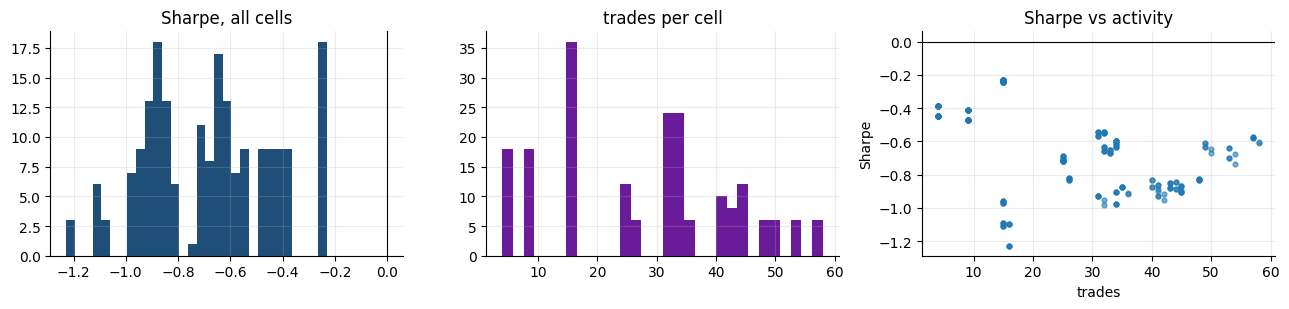

In [5]:
LIQ = GRID[GRID["n_trades"] >= MIN_TRADES].copy()
cols = ["root", "arm", "entry_richness", "max_hold", "take_profit", "n_trades", "hit_rate",
        "total_volbp", "sharpe", "t_nw", "top3_share"]
display(LIQ.sort_values("sharpe", ascending=False)[cols].head(20).round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(GRID["sharpe"], bins=30, color="#1f4e79"); axes[0].set_title("Sharpe, all cells")
axes[0].axvline(0, color="k", lw=.8)
axes[1].hist(GRID["n_trades"], bins=30, color="#6a1b9a"); axes[1].set_title("trades per cell")
axes[2].scatter(GRID["n_trades"], GRID["sharpe"], s=12, alpha=.6); axes[2].axhline(0, color="k", lw=.8)
axes[2].set_xlabel("trades"); axes[2].set_ylabel("Sharpe"); axes[2].set_title("Sharpe vs activity")
plt.tight_layout(); plt.show()

## 5. E[max Sharpe | null] — read this before the leaderboard

In [6]:
num = pd.to_numeric(LIQ["sharpe"], errors="coerce").dropna()
n_trials, var = int(num.size), float(num.var(ddof=1))
emax = A.expected_max_sharpe(n_trials, var)
print(f"trials {n_trials} | best {num.max():.3f} | E[max|null] {emax:.3f} | "
      f"median {num.median():.3f} | positive {100*(num>0).mean():.0f}%")
print("the winner of the whole search is BELOW chance" if num.max() < emax else
      "the winner clears the null; check the rest of the battery")

by = GRID.groupby(["root", "arm"])["sharpe"].agg(["count", "median", "max"]).round(3)
display(by)

trials 162 | best -0.230 | E[max|null] 0.638 | median -0.721 | positive 0%
the winner of the whole search is BELOW chance


count  median    max
root arm                      
UB   A       27  -0.448 -0.246
     B       27  -0.390 -0.230
ZB   A       36  -0.678 -0.552
     B       36  -0.684 -0.542
ZN   A       36  -0.875 -0.579
     B       36  -0.868 -0.571

## 6. Verdict

In [7]:
vp = RESULTS / "v3_verdict.json"
if vp.exists():
    V = json.loads(vp.read_text())
    display(pd.Series({k: v for k, v in V.items() if not isinstance(v, (dict, list))}).to_frame("value"))
    print("ablation:", json.dumps(V.get("ablation", {}), indent=1))
    print(f"\nALIVE = {V.get('alive')}")
else:
    print("run `python -m RVUtils.BasisVsVol.run_v3_grid` first")

,value
best_key,UB/B/e1.1/x1/h10/tp4/cm1
best_arm,B
sharpe,-0.229817
t_nw,-0.682747
n_trades,15
hit_rate,0.533333
total_32nds,-10.759741
top3_share,-1.016985
n_trials,162
expected_max_sharpe_null,0.638482


ablation: {
 "A: long basis (richness)": -0.2455127000312198,
 "B: basis vs swaption": -0.22981746693329008,
 "C: cheap net basis only": -0.39459031708246306
}

ALIVE = False
